In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchinfo import summary
from torchviz import make_dot
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
import torchvision.datasets as datasets
import sys
import os

In [2]:
# Import custom module
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

%load_ext autoreload
%autoreload 2

from modules.Contrastive_Divergence_Minimisation import InteractionSufficientStatistics, ExponentialFamilyModel
from modules.Annealed_Importance_Sampling import compute_exact_kl_divergence

In [3]:
# set devise
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# prepare MNIST data
transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = datasets.MNIST(root='./data', train=True, download=False, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=False, transform=transform)

train_loader = DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=64, shuffle=False)

Using device: cpu


In [7]:
# define 28*28 -> 50 -> 10 -> 5 -> 5 -> 5 -> 10 network
class MNISTNet(nn.Module):
    def __init__(self):
        super(MNISTNet, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(784, 50)
        self.fc2 = nn.Linear(50, 10)
        self.fc3 = nn.Linear(10, 5)
        self.fc4 = nn.Linear(5, 5)
        self.fc5 = nn.Linear(5, 5)
        self.fc6 = nn.Linear(5, 10)
        self._initialize_weights()
    
    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0.0)

    def forward(self, x):
        x = self.flatten(x)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = torch.relu(self.fc3(x))
        x = torch.relu(self.fc4(x))
        x = torch.relu(self.fc5(x))
        x = self.fc6(x)
        return x
    
    def get_activations(self, x):
        x = self.flatten(x)
        act1 = torch.relu(self.fc1(x))
        act2 = torch.relu(self.fc2(act1))
        act3 = torch.relu(self.fc3(act2))
        act4 = torch.relu(self.fc4(act3))
        act5 = torch.relu(self.fc5(act4))
        act6 = self.fc6(act5)

        _, predicted = torch.max(act6, 1)

        return {
            'L1': act1.detach().cpu().numpy(),
            'L2': act2.detach().cpu().numpy(),
            'L3': act3.detach().cpu().numpy(),
            'L4': act4.detach().cpu().numpy(),
            'L5': act5.detach().cpu().numpy(),
            'L6': act6.detach().cpu().numpy(),
            'predicted': predicted.detach().cpu().numpy()
        }

In [10]:
max_order = 5 # 組み合わせ爆発を防ぐための打ち切り次数
calc_stats = InteractionSufficientStatistics(max_order=max_order)

epochs = 1000 
calc_interval = 10

# initialise model
model = MNISTNet().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001)
cdm_models_persist = {}
cdm_optimizers_persist = {}
is_cdm_initialized = False
complexity_history = []
test_accuracy_history = []

for epoch in range(epochs):
    # ==========================================
    # 1. learning phase
    # ==========================================
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(train_loader):.4f}")
    
    # ==========================================
    # 2. obtain activation
    # ==========================================
    l1, l2, l3, l4, l5, l6 = [], [], [], [], [], []
    predictions = []
    
    model.eval() 
    with torch.no_grad(): 
        correct = 0
        total = 0
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            _, predicted_labels = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted_labels == labels).sum().item()
            
            activations = model.get_activations(images)
            l1.append(activations['L1'])
            l2.append(activations['L2'])
            l3.append(activations['L3'])
            l4.append(activations['L4'])
            l5.append(activations['L5'])
            l6.append(activations['L6'])
            predictions.append(activations['predicted'])
            
    l1 = np.vstack(l1)
    l2 = np.vstack(l2)
    l3 = np.vstack(l3)
    l4 = np.vstack(l4)
    l5 = np.vstack(l5)
    l6 = np.vstack(l6)
    predictions = np.concatenate(predictions)
    
    test_acc = 100.0 * correct / total
    
    print(f"Accuracy in epoch {epoch + 1}: {test_acc}%")
    # ==========================================
    # 3. Information Geometry / CDM Phase
    # ==========================================
    if epoch == 0 or (epoch+1) % calc_interval == 0:
        test_accuracy_history.append(test_acc)
        print(f"--- Starting CDM & KL Computation for Epoch {epoch + 1} ---")
        S_all = l3  # NumPy配列のまま保持 (ここではまだGPUに乗せない)
        T_all = predictions
        num_samples = len(S_all)
        
        cdm_batch_size = 512
        
        global_pos_mean = {k: 0.0 for k in range(max_order + 1)}
        
        # ミニバッチごとに計算して合計していく
        with torch.no_grad():
            for i in range(0, num_samples, cdm_batch_size):
                S_batch = torch.tensor(S_all[i:i+cdm_batch_size], dtype=torch.float32).to(device)
                T_batch = torch.tensor(T_all[i:i+cdm_batch_size], dtype=torch.long).to(device)
                T_onehot_batch = F.one_hot(T_batch, num_classes=10).float()
                
                pos_stats_batch = calc_stats(T_onehot_batch, S_batch)
                pos_stats_batch[0] = T_onehot_batch
                
                for k in range(max_order + 1):
                    global_pos_mean[k] += pos_stats_batch[k].sum(dim=0)
                    
            # 最後に全体のデータ数で割って「真の期待値」にする
            for k in range(max_order + 1):
                global_pos_mean[k] /= num_samples

        # ----------------------------------------------------
        # Phase B: モデルの初期化と 0次の解析的フィッティング
        # ----------------------------------------------------
        if not is_cdm_initialized:
            for k in range(max_order + 1):
                stats_dim = global_pos_mean[k].shape[0]
                cdm_models_persist[k] = ExponentialFamilyModel(stats_dim=stats_dim).to(device)
                if k > 0:
                    # ★ SGD ではなく Adam を推奨します
                    cdm_optimizers_persist[k] = torch.optim.Adam(cdm_models_persist[k].parameters(), lr=0.0001)
            is_cdm_initialized = True

        # 0次は毎回解析的に一瞬でフィッティング
        with torch.no_grad():
            eps = 1e-8
            cdm_models_persist[0].theta.copy_(torch.log(global_pos_mean[0] + eps))
        
        # ----------------------------------------------------
        # Phase C: k=1 から max_order までの最適化 (SGD)
        # ----------------------------------------------------
        # インナーループのエポック数（モデルが収束するまでの周回数）
        cd_epochs = max(10, int(500 / np.sqrt(epoch + 1)))
        current_lr = min(0.001, 0.0001 * np.sqrt(epoch + 1))
        
        for k in range(1, max_order + 1):
            current_model = cdm_models_persist[k]
            current_optimizer = cdm_optimizers_persist[k]
            
            # 動的学習率の適用
            for param_group in current_optimizer.param_groups:
                param_group['lr'] = current_lr
            
            # ★ 修正: コピーしていいのは一番最初の「初回エポック」だけ！
            if epoch == 0:
                with torch.no_grad():
                    prev_dim = cdm_models_persist[k-1].theta.shape[0]
                    current_model.theta[:prev_dim].copy_(cdm_models_persist[k-1].theta)
                    
            # パラメータ収束のための学習ループ
            for inner_epoch in range(cd_epochs):
                indices = np.random.permutation(num_samples)
                for i in range(0, num_samples, cdm_batch_size):
                    idx = indices[i:i+cdm_batch_size]
                    S_batch = torch.tensor(S_all[idx], dtype=torch.float32).to(device)
                    
                    neg_mean_batch = current_model.compute_negative_stats_mean(
                        S_batch=S_batch, 
                        calc_stats_fn=calc_stats, 
                        k=k
                    )
                    
                    loss_val = current_model.contrastive_divergence_step(
                        optimizer=current_optimizer, 
                        pos_mean=global_pos_mean[k],
                        neg_mean=neg_mean_batch
                    )
        
        # ----------------------------------------------------
        # 4. compute KL
        # ----------------------------------------------------
        print(f"Calculating exact KL Divergences for Epoch {epoch+1}...")
        
        kl_divergences = {}
        total_complexity_C = 0.0
        S_all_tensor = torch.tensor(S_all, dtype=torch.float32).to(device)
        
        for k in range(1, max_order + 1):
            kl_val = compute_exact_kl_divergence(
                model_k=cdm_models_persist[k],
                model_k_minus_1=cdm_models_persist[k-1],
                S_batch=S_all_tensor,
                calc_stats_fn=calc_stats,
                k=k
            )
            kl_divergences[k] = kl_val
            total_complexity_C += k * kl_val

        normalization_term = sum(kl_divergences.values())
        if normalization_term > 0:
            epoch_C = total_complexity_C / normalization_term
        else:
            epoch_C = 0.0
            
        complexity_history.append(epoch_C)
        print(f"Epoch [{epoch+1}/{epochs}] - Representation Complexity C: {epoch_C:.6f}\n")

Epoch [1/1000], Loss: 2.2122
Accuracy in epoch 1: 18.46%
--- Starting CDM & KL Computation for Epoch 1 ---
Calculating exact KL Divergences for Epoch 1...
Epoch [1/1000] - Representation Complexity C: 1.478084

Epoch [2/1000], Loss: 2.0801
Accuracy in epoch 2: 20.84%
Epoch [3/1000], Loss: 2.0100
Accuracy in epoch 3: 22.15%
Epoch [4/1000], Loss: 1.9525
Accuracy in epoch 4: 24.0%
Epoch [5/1000], Loss: 1.8961
Accuracy in epoch 5: 24.88%
Epoch [6/1000], Loss: 1.8392
Accuracy in epoch 6: 27.7%
Epoch [7/1000], Loss: 1.7822
Accuracy in epoch 7: 33.71%
Epoch [8/1000], Loss: 1.7287
Accuracy in epoch 8: 35.16%
Epoch [9/1000], Loss: 1.6788
Accuracy in epoch 9: 36.52%
Epoch [10/1000], Loss: 1.6327
Accuracy in epoch 10: 38.03%
--- Starting CDM & KL Computation for Epoch 10 ---
Calculating exact KL Divergences for Epoch 10...
Epoch [10/1000] - Representation Complexity C: 1.327785

Epoch [11/1000], Loss: 1.5899
Accuracy in epoch 11: 39.93%
Epoch [12/1000], Loss: 1.5496
Accuracy in epoch 12: 42.38%
E

In [11]:
with torch.no_grad():
    correct = 0
    total = 0
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"\nAccuracy on the test data: {100 * correct / total:.2f}%")


Accuracy on the test data: 93.08%


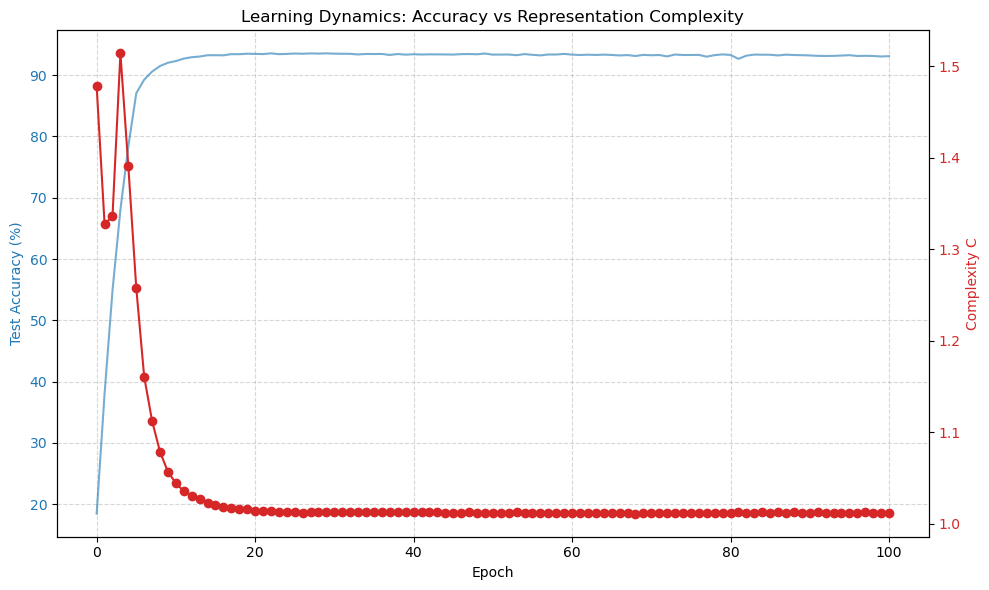

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# データの準備 (もし必要ならここでepochを+1補正)
epochs = np.arange(len(test_accuracy_history)) 
# もしepoch 0スタートでintervalが少しズレていたなら、
# 記録したエポック番号のリストを作っておくのが一番確実です
# recorded_epochs = [0, 10, 20, ...] 

fig, ax1 = plt.subplots(figsize=(10, 6))

# 1. Accuracyのプロット (左軸)
color = 'tab:blue'
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Test Accuracy (%)', color=color)
ax1.plot(epochs, test_accuracy_history, color=color, label='Accuracy', alpha=0.6)
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle='--', alpha=0.5)

# 2. Complexity C のプロット (右軸)
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Complexity C', color=color)
# Cの履歴は間引かれているはずなので、対応するepochでプロットしてください
# 例: ax2.plot(recorded_epochs, complexity_history, color=color, marker='o', label='Complexity C')
ax2.plot(complexity_history, color=color, marker='o', label='Complexity C') 
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Learning Dynamics: Accuracy vs Representation Complexity')
fig.tight_layout()
plt.show()